In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
np.random.seed(42)

# Generate larger dataset
n = 1000

dates = pd.date_range(start="2023-01-01", periods=365)

df = pd.DataFrame({
    "InvoiceNo": np.random.randint(1000, 5000, n),
    "CustomerID": np.random.randint(10000, 10200, n),
    "ProductID": np.random.randint(200, 500, n),
    "Product": np.random.choice(["Laptop", "Phone", "Tablet", "Headphones", "Monitor"], n),
    "Category": np.random.choice(["Electronics", "Accessories"], n),
    "Quantity": np.random.randint(1, 10, n),
    "UnitPrice": np.random.uniform(20, 1000, n),
    "Discount": np.random.uniform(0, 0.3, n),
    "PaymentMethod": np.random.choice(["Card", "UPI", "Cash"], n),
    "Country": np.random.choice(["USA", "UK", "Canada", "India"], n),
    "City": np.random.choice(["New York", "London", "Toronto", "Mumbai"], n),
    "CustomerAge": np.random.randint(18, 65, n),
    "CustomerGender": np.random.choice(["Male", "Female"], n),
    "SignupDate": np.random.choice(dates, n),
    "InvoiceDate": np.random.choice(dates, n),
    "ShippingCost": np.random.uniform(5, 50, n),
    "DeliveryTimeDays": np.random.randint(1, 10, n),
    "ReturnStatus": np.random.choice(["Yes", "No"], n),
    "CustomerTenure": np.random.randint(1, 5, n),
    "Device": np.random.choice(["Mobile", "Desktop"], n)
})

# Derived columns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['SignupDate'] = pd.to_datetime(df['SignupDate'])

df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
df['Profit'] = df['Revenue'] * np.random.uniform(0.1, 0.3, n)
df['OrderValue'] = df['Revenue'] + df['ShippingCost']

df.head()

,InvoiceNo,CustomerID,ProductID,Product,Category,Quantity,UnitPrice,Discount,PaymentMethod,Country,...,SignupDate,InvoiceDate,ShippingCost,DeliveryTimeDays,ReturnStatus,CustomerTenure,Device,Revenue,Profit,OrderValue
0,4174,10108,244,Tablet,Accessories,2,331.622900,0.133069,Card,India,...,2023-11-22,2023-02-26,17.307629,7,Yes,1,Desktop,574.988343,161.445458,592.295972
1,4507,10004,380,Laptop,Accessories,6,588.136543,0.281663,UPI,USA,...,2023-01-02,2023-05-22,10.471431,7,Yes,3,Desktop,2534.881112,275.969573,2545.352543
2,1860,10118,369,Monitor,Accessories,4,358.712494,0.088484,Card,UK,...,2023-06-01,2023-07-29,30.022580,7,Yes,3,Desktop,1307.889072,215.132390,1337.911652
3,2294,10032,390,Headphones,Accessories,3,819.454017,0.142639,Cash,Canada,...,2023-12-31,2023-03-13,19.713993,2,No,3,Mobile,2107.703544,450.700699,2127.417537
4,2130,10117,354,Phone,Electronics,3,477.393532,0.227078,Cash,USA,...,2023-03-06,2023-08-12,24.912109,2,Yes,3,Mobile,1106.963464,225.342646,1131.875573


In [5]:
df.shape

(1000, 23)

In [6]:
# --- Data Cleaning ---

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (if any)
df = df.dropna()

# Filter invalid data
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# --- Feature Engineering ---

# Time-based features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['WeekOfYear'] = df['InvoiceDate'].dt.isocalendar().week

# Customer behavior features
df['CustomerLifetimeDays'] = (df['InvoiceDate'] - df['SignupDate']).dt.days

# Profit Margin
df['ProfitMargin'] = df['Profit'] / df['Revenue']

# Average Order Value per Customer
df['AvgOrderValue'] = df.groupby('CustomerID')['OrderValue'].transform('mean')

# High Value Customer Flag
df['HighValueCustomer'] = np.where(df['Revenue'] > df['Revenue'].quantile(0.75), 1, 0)

df.head()

,InvoiceNo,CustomerID,ProductID,Product,Category,Quantity,UnitPrice,Discount,PaymentMethod,Country,...,OrderValue,Year,Month,Day,DayOfWeek,WeekOfYear,CustomerLifetimeDays,ProfitMargin,AvgOrderValue,HighValueCustomer
0,4174,10108,244,Tablet,Accessories,2,331.622900,0.133069,Card,India,...,592.295972,2023,2,26,6,8,-269,0.280780,1651.801469,0
1,4507,10004,380,Laptop,Accessories,6,588.136543,0.281663,UPI,USA,...,2545.352543,2023,5,22,0,21,140,0.108869,1850.958112,0
2,1860,10118,369,Monitor,Accessories,4,358.712494,0.088484,Card,UK,...,1337.911652,2023,7,29,5,30,58,0.164488,1345.040155,0
3,2294,10032,390,Headphones,Accessories,3,819.454017,0.142639,Cash,Canada,...,2127.417537,2023,3,13,0,11,-293,0.213835,2874.004486,0
4,2130,10117,354,Phone,Electronics,3,477.393532,0.227078,Cash,USA,...,1131.875573,2023,8,12,5,32,159,0.203568,2545.815483,0


In [7]:
# --- RFM Analysis ---

# Reference date (latest date in dataset)
snapshot_date = df['InvoiceDate'].max()

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',                                     # Frequency
    'Revenue': 'sum'                                          # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
10000,32,9,20269.978271
10001,210,1,1896.505849
10002,8,7,13073.341593
10003,44,6,17735.320737
10004,23,10,18293.132820


In [8]:
# RFM Scoring (1–4 scale)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Combine scores
rfm['RFM_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
10000,32,9,20269.978271,3,4,4,11
10001,210,1,1896.505849,1,1,1,3
10002,8,7,13073.341593,4,3,3,10
10003,44,6,17735.320737,3,3,4,10
10004,23,10,18293.132820,3,4,4,11


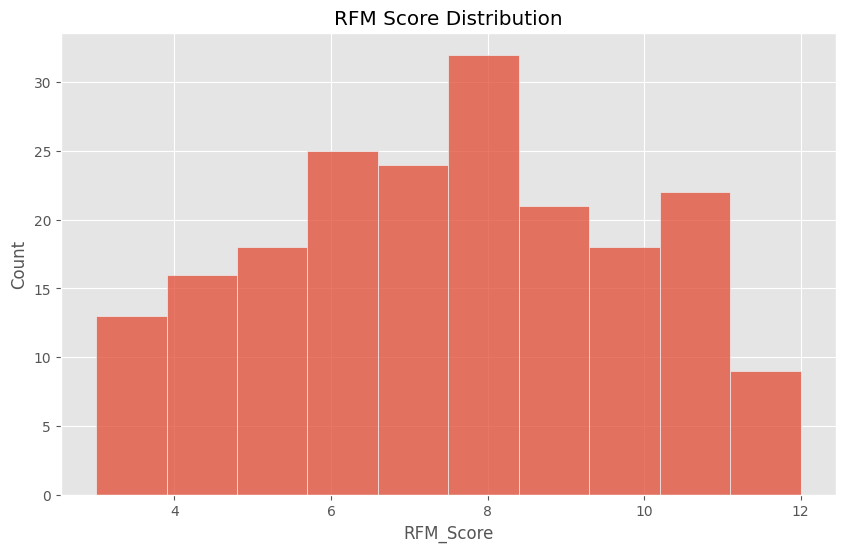

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(rfm['RFM_Score'], bins=10)
plt.title("RFM Score Distribution")
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
CustomerID,,,,,,,,
10000,32,9,20269.978271,3,4,4,11,1
10001,210,1,1896.505849,1,1,1,3,3
10002,8,7,13073.341593,4,3,3,10,2
10003,44,6,17735.320737,3,3,4,10,2
10004,23,10,18293.132820,3,4,4,11,1


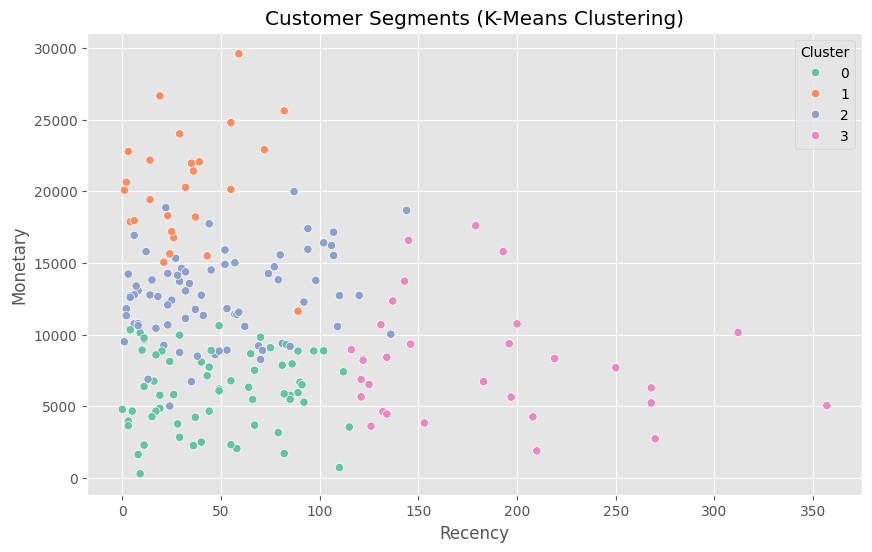

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set2'
)

plt.title("Customer Segments (K-Means Clustering)")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

In [13]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,49.380952,3.365079,6053.122626
1,32.500000,9.115385,20328.571818
2,47.717949,5.833333,12625.025896
3,181.225806,3.096774,8057.551339


In [14]:
# --- Create Cohort Data ---

# Cohort = first purchase month
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'] \
                      .transform('min') \
                      .dt.to_period('M')

# Order month
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

# Group data
cohort_data = df.groupby(['CohortMonth', 'OrderMonth']) \
                .agg({'CustomerID': 'nunique'}) \
                .reset_index()

# Cohort Index (months since first purchase)
cohort_data['CohortIndex'] = (
    cohort_data['OrderMonth'] - cohort_data['CohortMonth']
).apply(lambda x: x.n)

cohort_data.head()

,CohortMonth,OrderMonth,CustomerID,CohortIndex
0,2023-01,2023-01,69,0
1,2023-01,2023-02,28,1
2,2023-01,2023-03,29,2
3,2023-01,2023-04,24,3
4,2023-01,2023-05,23,4


In [15]:
cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortMonth,,,,,,,,,,,,
2023-01,69.0,28.0,29.0,24.0,23.0,27.0,20.0,29.0,19.0,32.0,24.0,27.0
2023-02,45.0,21.0,15.0,17.0,16.0,11.0,15.0,18.0,14.0,16.0,17.0,NaN
2023-03,22.0,10.0,6.0,10.0,7.0,3.0,9.0,13.0,5.0,7.0,NaN,NaN
2023-04,24.0,5.0,4.0,11.0,7.0,14.0,8.0,8.0,8.0,NaN,NaN,NaN
2023-05,12.0,4.0,4.0,5.0,5.0,3.0,3.0,3.0,NaN,NaN,NaN,NaN
2023-06,7.0,1.0,3.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2023-07,7.0,3.0,2.0,4.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,3.0,1.0,1.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,4.0,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


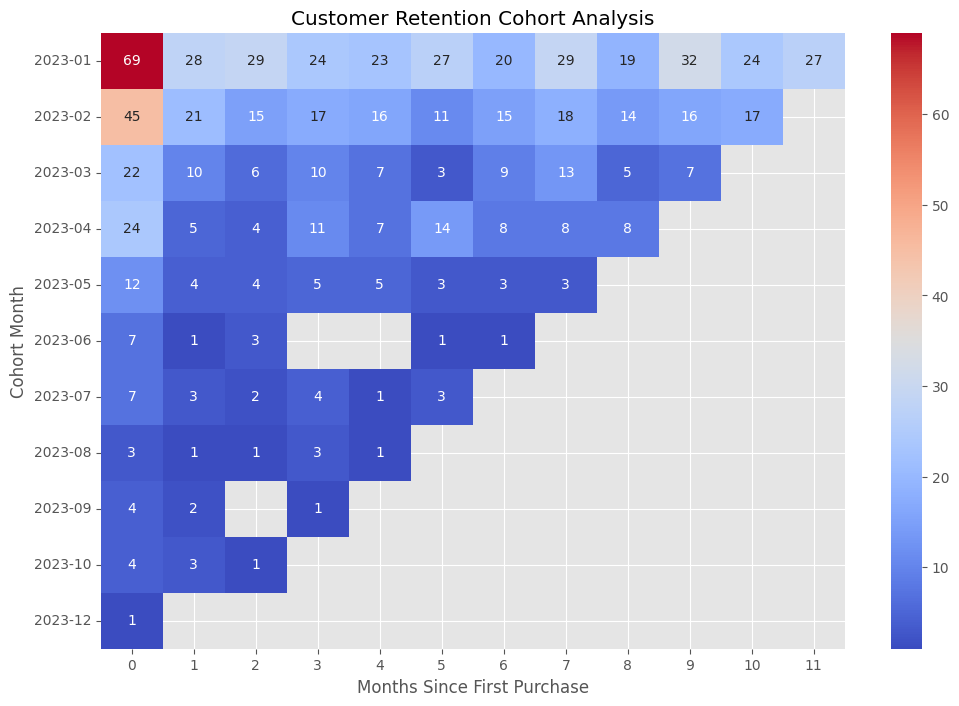

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(cohort_pivot, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

In [17]:
# --- Daily Revenue Time Series ---

daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum()

# Convert to proper datetime index
daily_revenue.index = pd.to_datetime(daily_revenue.index)

# Fill missing dates
daily_revenue = daily_revenue.asfreq('D').fillna(0)

daily_revenue.head()

,Revenue
InvoiceDate,
2023-01-01,253.980284
2023-01-02,3710.280272
2023-01-03,3759.462954
2023-01-04,63.171005
2023-01-05,9681.251561


In [18]:
from statsmodels.tsa.arima.model import ARIMA

# Build model
model = ARIMA(daily_revenue, order=(5,1,2))

# Fit model
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  365
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -3602.456
Date:                Tue, 28 Apr 2026   AIC                           7220.913
Time:                        14:06:21   BIC                           7252.090
Sample:                    01-01-2023   HQIC                          7233.304
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8702      0.111     -7.868      0.000      -1.087      -0.653
ar.L2          0.2253      0.077      2.939      0.003       0.075       0.376
ar.L3          0.0762      0.083      0.921      0.3

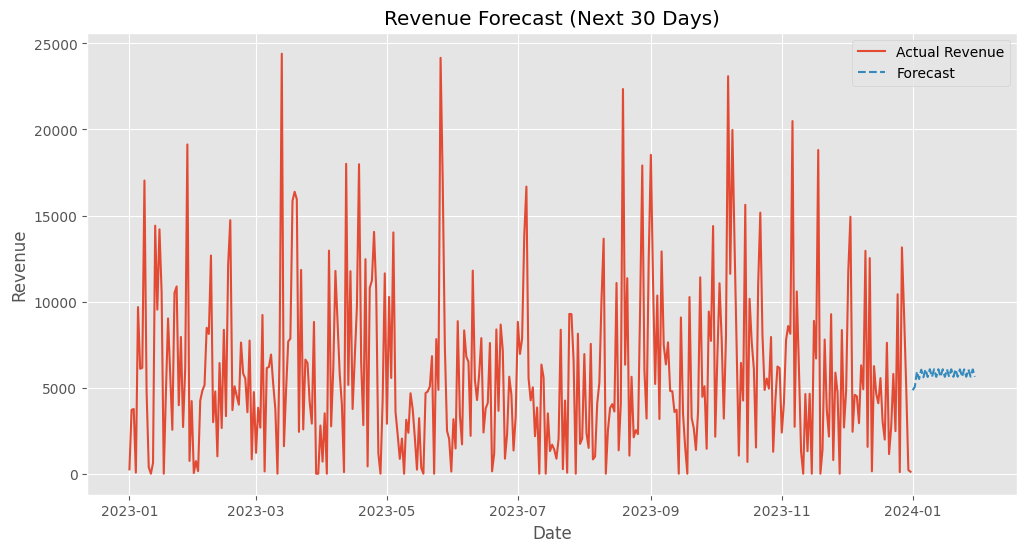

In [19]:
# Forecast next 30 days
forecast = model_fit.forecast(steps=30)

# Plot
plt.figure(figsize=(12,6))

plt.plot(daily_revenue, label='Actual Revenue')
plt.plot(forecast, label='Forecast', linestyle='dashed')

plt.title("Revenue Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()

In [20]:
from sklearn.ensemble import IsolationForest

# Prepare data
ts_df = daily_revenue.reset_index()
ts_df.columns = ['Date', 'Revenue']

# Train model
model_iso = IsolationForest(contamination=0.02, random_state=42)
ts_df['Anomaly'] = model_iso.fit_predict(ts_df[['Revenue']])

ts_df.head()

,Date,Revenue,Anomaly
0,2023-01-01,253.980284,1
1,2023-01-02,3710.280272,1
2,2023-01-03,3759.462954,1
3,2023-01-04,63.171005,1
4,2023-01-05,9681.251561,1


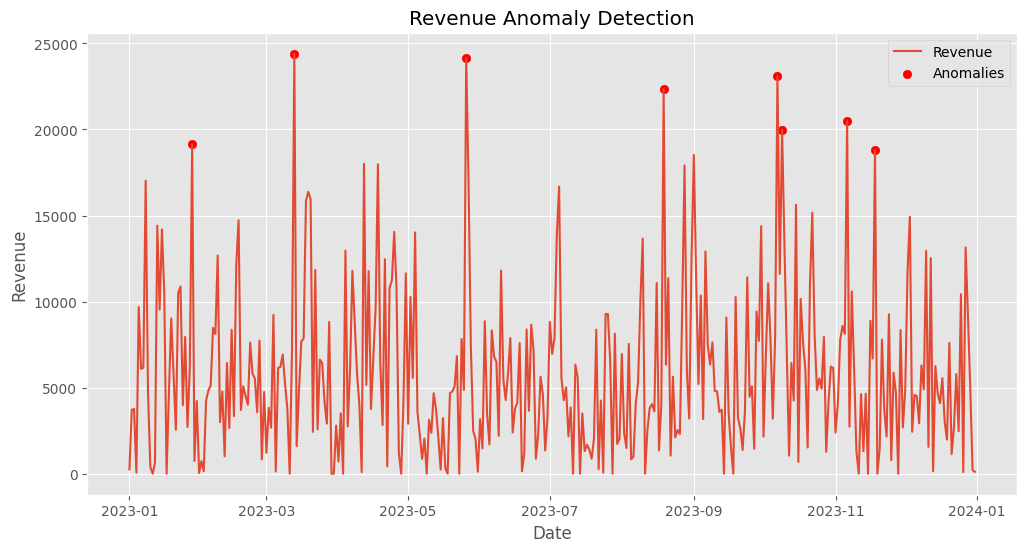

In [21]:
plt.figure(figsize=(12,6))

# Plot revenue
plt.plot(ts_df['Date'], ts_df['Revenue'], label='Revenue')

# Highlight anomalies
anomalies = ts_df[ts_df['Anomaly'] == -1]
plt.scatter(anomalies['Date'], anomalies['Revenue'], color='red', label='Anomalies')

plt.title("Revenue Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()

In [22]:
df.to_csv("ecommerce_data.csv", index=False)

In [23]:
rfm.to_csv("rfm_customer_segments.csv")

In [24]:
daily_revenue.to_csv("daily_revenue.csv")